In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, integrate

 - https://stackoverflow.com/questions/78593373/fitting-a-planck-curve-on-my-spectrometer-data
 - https://en.wikipedia.org/wiki/Planck%27s_law

In [2]:
data = pd.read_csv("https://pastebin.com/raw/xdLY6aLG", sep="\t", decimal=",").iloc[:,:2]

In [3]:
data["Wavelength"] /= 1e9

In [4]:
I0 = integrate.trapezoid(data["Intensity"], x=data["Wavelength"])
I0

np.float64(2.6150815404e-05)

In [5]:
h = 6.62607015e-34
c = 299792458
kb = 1.380649e-23

In [6]:
def model(l, A, T):
    """Radiance as a function of wavelength"""
    return A * (2. * h * c ** 2 / l ** 5) * (1 / (np.exp(h * c / (l * kb * T)) - 1.))

In [7]:
def model(l, A, T):
    """Spectral energy as a function of wavelength"""
    return A * (8. * np.pi * h * c / l ** 5) * (1 / (np.exp(h * c / (l * kb * T)) - 1.))

In [8]:
llin = np.linspace(1e-7, 9e-6, 200)
Ilin = model(llin, 1, 5000)

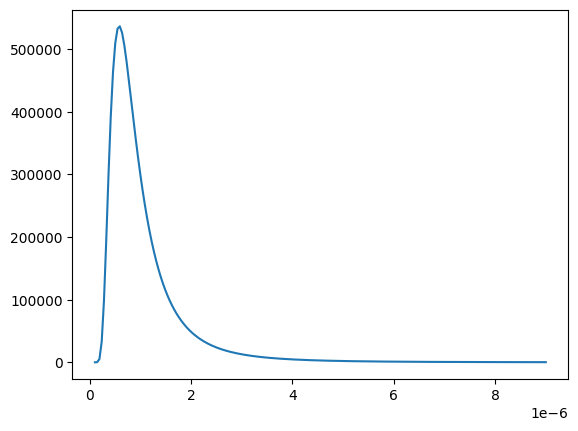

In [9]:
fig, axe = plt.subplots()
axe.plot(llin, Ilin)

In [10]:
Iref = integrate.trapezoid(Ilin, x=llin)
Iref

np.float64(0.472156066151361)

In [11]:
popt, pcov = optimize.curve_fit(model, data["Wavelength"], data["Intensity"], p0=(1., 5e3))
popt, pcov

(array([1.56629538e-04, 4.61299664e+03]),
 array([[ 6.20402518e-11, -3.54617042e-04],
        [-3.54617042e-04,  2.12790142e+03]]))

In [12]:
Ihat = model(data["Wavelength"], *popt)

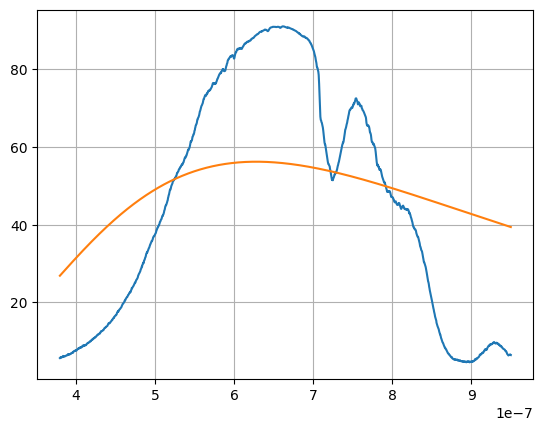

In [13]:
fig, axe = plt.subplots()
axe.plot(data["Wavelength"], data["Intensity"])
axe.plot(data["Wavelength"], Ihat)
axe.grid()